In [ ]:
from benchmarks.alsc_convergence import ARGS_alsc_convergence, alsc_convergence
stats = {}
for tree_type in ['linear', 'balanced', 'weighted']:
# for tree_type in ['linear']:
  args = ARGS_alsc_convergence(
    tree_type = tree_type,
    Ny_decay = True,
    alsc_rinit = 5,
    alsc_kickrank = 5,
    verbose = 1
  )
  stats[tree_type] = alsc_convergence(args)

/home/benno/dev/TT-IRT/python/htucker/benchmarks/alsc_convergence.py:104: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  if args.verbose: print('\s[', iter*'=', '>', (args.alsc_niter-iter-1)* ' ', f'](iter {iter})', end='')


Computing coefficient TT approximation


/home/benno/dev/TT-IRT/python/htucker/tree_tensor/tree_tensor_torch.py:45: RuntimeWarning: overflow encountered in square
  S1 = np.cumsum(np.square(S1))


swp:  1/15 f_evals=48280 self.max_dx=inf
swp:  2/15 f_evals=100105 self.max_dx=2.92e-01
swp:  3/15 f_evals=173254 self.max_dx=1.13e-01
swp:  4/15 f_evals=285520 self.max_dx=1.97e-01
swp:  5/15 f_evals=447106 self.max_dx=8.59e-02
swp:  6/15 f_evals=674773 self.max_dx=4.31e-02
swp:  7/15 f_evals=973400 self.max_dx=3.37e-02
swp:  8/15 f_evals=1362371 self.max_dx=1.69e-02
swp:  9/15 f_evals=1871843 self.max_dx=2.75e-02
swp: 10/15 f_evals=2482019 self.max_dx=2.91e-02
swp: 11/15 f_evals=3184556 self.max_dx=1.03e-02
swp: 12/15 f_evals=3976173 self.max_dx=8.34e-03
swp: 13/15 f_evals=4849109 self.max_dx=7.67e-03
swp: 14/15 f_evals=5812412 self.max_dx=7.82e-03
swp: 15/15 f_evals=6834170 self.max_dx=1.88e-03
Coefficient TT RMS l2 err = 1.39e-03
Init finished
\s[  >      ](iter 0)= swp=0
= swp=0 finished, max_dx=1.94e+150
\s[ = >     ](iter 1)= swp=0
= swp=0 finished, max_dx=7.96e-02
\s[ == >    ](iter 2)= swp=0
= swp=0 finished, max_dx=9.64e-04
\s[ === >   ](iter 3)= swp=0
= swp=0 finished, max_d

/home/benno/dev/TT-IRT/python/htucker/tree_tensor/tree_tensor_torch.py:45: RuntimeWarning: overflow encountered in square
  S1 = np.cumsum(np.square(S1))


swp:  1/15 f_evals=63688 self.max_dx=inf
swp:  2/15 f_evals=134074 self.max_dx=5.45e+00
swp:  3/15 f_evals=247970 self.max_dx=6.91e+00
swp:  4/15 f_evals=418329 self.max_dx=3.31e+00
swp:  5/15 f_evals=652175 self.max_dx=1.06e+00
swp:  6/15 f_evals=998650 self.max_dx=7.08e-01
swp:  7/15 f_evals=1535168 self.max_dx=6.08e-01
swp:  8/15 f_evals=2348664 self.max_dx=3.69e-02
swp:  9/15 f_evals=3502905 self.max_dx=1.30e-02
swp: 10/15 f_evals=4965028 self.max_dx=7.13e-03
swp: 11/15 f_evals=6596193 self.max_dx=2.27e-03
swp: 12/15 f_evals=8339229 self.max_dx=1.35e-03
swp: 13/15 f_evals=10126176 self.max_dx=4.89e-04
swp: 14/15 f_evals=11974191 self.max_dx=6.66e-04
swp: 15/15 f_evals=13859354 self.max_dx=4.39e-04
Coefficient TT RMS l2 err = 6.26e-04
Init finished
\s[  >      ](iter 0)= swp=0
= swp=0 finished, max_dx=1.52e+151
\s[ = >     ](iter 1)= swp=0
= swp=0 finished, max_dx=4.75e-01
\s[ == >    ](iter 2)= swp=0
= swp=0 finished, max_dx=4.06e-03
\s[ === >   ](iter 3)= swp=0
= swp=0 finished, m

In [2]:
import pickle
stats = {}
with open('data/stats_415768A2BB8DDD53.pkl', mode='rb') as file:
  args, s = pickle.load(file)
  stats['linear'] = s
with open('data/stats_6E74D9E21A81EE4F.pkl', mode='rb') as file:
  args, s = pickle.load(file)
  stats['balanced'] = s
with open('data/stats_5AFDDB1BB915580E.pkl', mode='rb') as file:
  args, s = pickle.load(file)
  stats['weighted'] = s

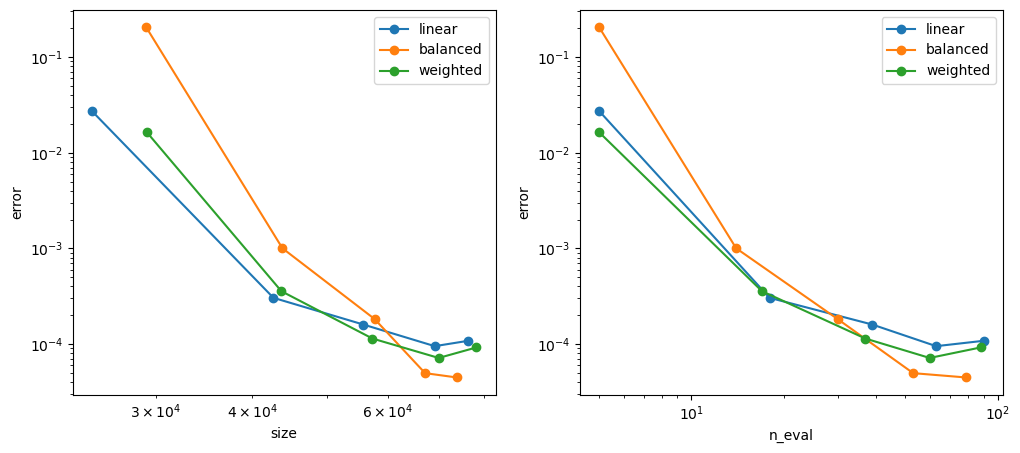

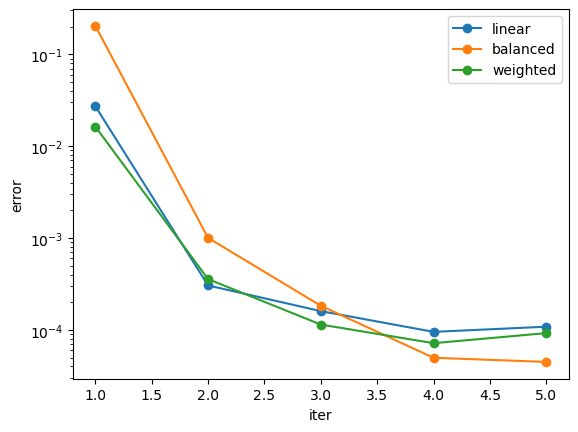

In [5]:
import matplotlib.pyplot as plt
from benchmarks.alsc_convergence import RMS

fig, axs = plt.subplots(1, 2, figsize=(12,5))

for tree_type, stat in stats.items():
  
  axs[0].plot(stat['size'], [RMS(e) for e in stat['error']], marker='o', label=tree_type)
  axs[1].plot(stat['alsc_n_eval'], [RMS(e) for e in stat['error']], marker='o', label=tree_type)

axs[0].set_xlabel('size')
axs[1].set_xlabel('n_eval')
for ax in axs:
  ax.set_xscale('log')
  ax.set_yscale('log')
  ax.set_ylabel('error')
  ax.legend()

fig, ax = plt.subplots()

for tree_type, stat in stats.items():
  ax.plot(np.arange(1, len(stat['size'])+1), [RMS(e) for e in stat['error']], marker='o', label=tree_type)
ax.set_xlabel('iter')
ax.set_yscale('log')
ax.set_ylabel('error')
ax.legend()

In [1]:
from benchmarks.alsc_accuracy_scaling import *
stats = {}
for tree_type in ['linear', 'balanced', 'weighted']:
# for tree_type in ['linear']:
  args = ARGS_alsc_accuracy_scaling(
    tree_type = tree_type,
    eps_steps = 5,
    eps_end=1e-7,
    cross_niter=30,
    verbose = 1
  )
  stats[tree_type] = alsc_accuracy_scaling(args)

Running accuracy scaling test...
ARGS_alsc_accuracy_scaling(verbose=1, Nx=100, Ny=10, Ny_decay=True, n_param=200, c_offset=1, c_var=4, c_decay=2.0, tree_type='linear', cross_niter=30, cross_kickrank=5, alsc_niter=5, alsc_kickrank=5, alsc_rinit=5, eps_start=1.0, eps_end=1e-07, eps_steps=5, rng_seed=0, N_mc=100)
Computing coefficient TT approximation


/home/benno/dev/TT-IRT/python/htucker/tree_tensor/tree_tensor_torch.py:45: RuntimeWarning: overflow encountered in square
  S1 = np.cumsum(np.square(S1))


swp:  1/30 f_evals=48604 self.max_dx=inf
swp:  2/30 f_evals=102118 self.max_dx=2.83e-01
swp:  3/30 f_evals=178054 self.max_dx=2.96e-01
swp:  4/30 f_evals=296327 self.max_dx=1.26e-01
swp:  5/30 f_evals=479033 self.max_dx=5.77e-02
swp:  6/30 f_evals=747269 self.max_dx=2.84e-02
swp:  7/30 f_evals=1125820 self.max_dx=3.92e-02
swp:  8/30 f_evals=1634566 self.max_dx=9.91e-03
swp:  9/30 f_evals=2272302 self.max_dx=1.82e-02
swp: 10/30 f_evals=3050247 self.max_dx=1.98e-02
swp: 11/30 f_evals=3995991 self.max_dx=1.30e-02
swp: 12/30 f_evals=5143152 self.max_dx=1.85e-02
swp: 13/30 f_evals=6497889 self.max_dx=3.68e-03
swp: 14/30 f_evals=8059177 self.max_dx=3.25e-03
swp: 15/30 f_evals=9835204 self.max_dx=3.05e-03
swp: 16/30 f_evals=11855893 self.max_dx=4.26e-03
swp: 17/30 f_evals=14137121 self.max_dx=2.97e-03
swp: 18/30 f_evals=16640152 self.max_dx=4.51e-03
swp: 19/30 f_evals=19359219 self.max_dx=5.62e-04
swp: 20/30 f_evals=22264056 self.max_dx=3.40e-04
swp: 21/30 f_evals=25299423 self.max_dx=2.15e-0

/home/benno/dev/TT-IRT/python/htucker/tree_tensor/tree_tensor_torch.py:45: RuntimeWarning: overflow encountered in square
  S1 = np.cumsum(np.square(S1))


swp:  1/30 f_evals=64948 self.max_dx=inf
swp:  2/30 f_evals=132896 self.max_dx=5.45e+00
swp:  3/30 f_evals=247913 self.max_dx=5.56e+00
swp:  4/30 f_evals=446333 self.max_dx=2.95e+00
swp:  5/30 f_evals=790963 self.max_dx=8.03e-01
swp:  6/30 f_evals=1372415 self.max_dx=7.98e-01
swp:  7/30 f_evals=2260766 self.max_dx=5.35e-01
swp:  8/30 f_evals=3647163 self.max_dx=6.14e-02
swp:  9/30 f_evals=5688509 self.max_dx=1.16e-02
swp: 10/30 f_evals=8404086 self.max_dx=3.05e-03
swp: 11/30 f_evals=11937298 self.max_dx=9.98e-04
swp: 12/30 f_evals=16154677 self.max_dx=2.98e-04
swp: 13/30 f_evals=20743330 self.max_dx=1.75e-05
swp: 14/30 f_evals=25613617 self.max_dx=8.43e-06
swp: 15/30 f_evals=30633652 self.max_dx=1.93e-06
swp: 16/30 f_evals=35663884 self.max_dx=5.67e-07
swp: 17/30 f_evals=40726546 self.max_dx=9.77e-07
swp: 18/30 f_evals=45804860 self.max_dx=3.29e-07
swp: 19/30 f_evals=50855422 self.max_dx=2.59e-07
swp: 20/30 f_evals=55942194 self.max_dx=5.19e-07
swp: 21/30 f_evals=61035565 self.max_dx=4

In [6]:
import pickle
stats = {}
with open('data/stats_204768836A71E4D7.pkl', mode='rb') as file:
  args, s = pickle.load(file)
  stats['linear'] = s
with open('data/stats_-11DF96A28AD615EC.pkl', mode='rb') as file:
  args, s = pickle.load(file)
  stats['balanced'] = s
with open('data/stats_-24A75476C71221D4.pkl', mode='rb') as file:
  args, s = pickle.load(file)
  stats['weighted'] = s

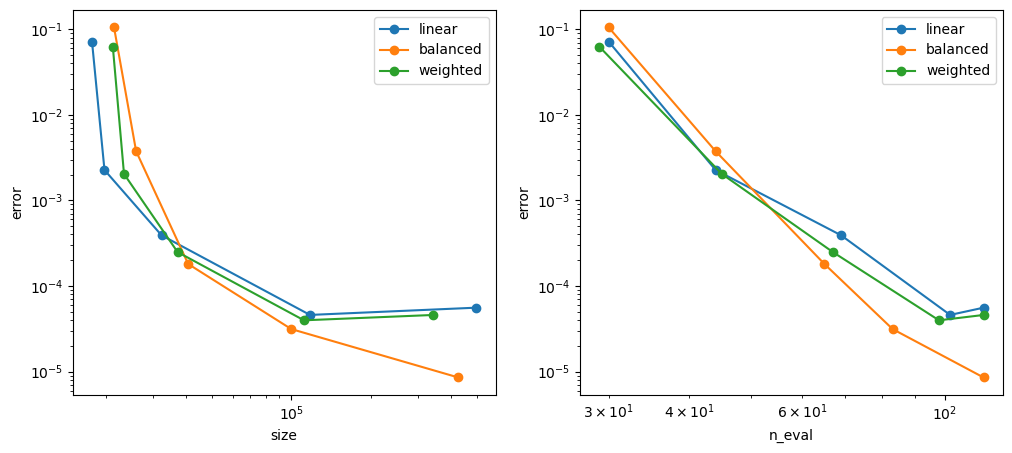

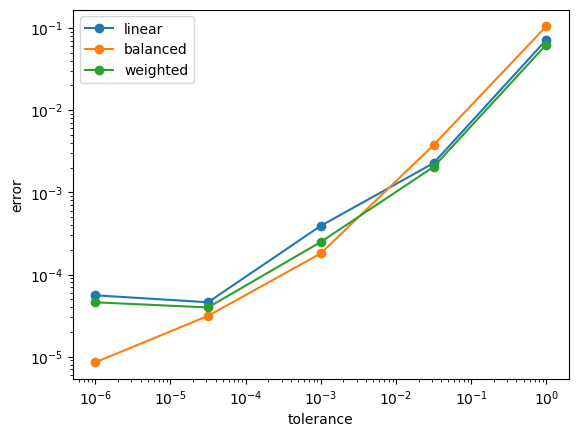

In [7]:
import matplotlib.pyplot as plt
from benchmarks.alsc_convergence import RMS

fig, axs = plt.subplots(1, 2, figsize=(12,5))

for tree_type, stat in stats.items():
  
  axs[0].plot(stat['size'], [RMS(e) for e in stat['error']], marker='o', label=tree_type)
  axs[1].plot(stat['alsc_n_eval'], [RMS(e) for e in stat['error']], marker='o', label=tree_type)

axs[0].set_xlabel('size')
axs[1].set_xlabel('n_eval')
for ax in axs:
  ax.set_xscale('log')
  ax.set_yscale('log')
  ax.set_ylabel('error')
  ax.legend()

fig, ax = plt.subplots()

for tree_type, stat in stats.items():
  ax.plot(stat['eps'], [RMS(e) for e in stat['error']], marker='o', label=tree_type)

ax.set_xlabel('tolerance')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('error')
ax.legend()